<a href="https://colab.research.google.com/github/DevKnight-code/Supply-Chain-Inventory-Optimization/blob/main/python/Supply_Chain_Inventory_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q xgboost openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving SupplyChain_Inventory_Planning_Analysis.xlsm to SupplyChain_Inventory_Planning_Analysis.xlsm


In [ ]:
filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

Uploaded file: SupplyChain_Inventory_Planning_Analysis.xlsm


In [ ]:
excel_file = pd.ExcelFile(filename, engine="openpyxl")

print("Available sheets:")
for sheet in excel_file.sheet_names:
    print("-", sheet)

Available sheets:
- CONTROL_PANEL
- Inventory data
- SupplierData
- Productdata
- Optimization_Data
- reorder_report
- LOGS
- Reorder_History
- SupplyChainAnalytics
- StockAlerts


In [ ]:
inventory = pd.read_excel(
    filename,
    sheet_name="Inventory data",
    engine="openpyxl"
)

products = pd.read_excel(
    filename,
    sheet_name="Productdata",
    engine="openpyxl"
)

suppliers = pd.read_excel(
    filename,
    sheet_name="SupplierData",
    engine="openpyxl"
)

optimization = pd.read_excel(
    filename,
    sheet_name="Optimization_Data",
    engine="openpyxl"
)

print("Inventory:", inventory.shape)
print("Products:", products.shape)
print("Suppliers:", suppliers.shape)
print("Optimization:", optimization.shape)

Inventory: (96360, 26)
Products: (90, 17)
Suppliers: (20, 9)
Optimization: (264, 29)


In [ ]:
columns = [
    "Date",
    "ProductID",
    "ProductName",
    "Category",
    "SupplierID",
    "WarehouseID",
    "WarehouseName",
    "OpeningStock",
    "UnitsReceived",
    "UnitsSold",
    "LostSales",
    "ClosingStock",
    "ObservedDemand",
    "StockoutFlag",
    "Promotion",
    "UnitCost",
    "UnitPrice"
]

df = inventory[columns].copy()

display(df.head())

,Date,ProductID,ProductName,Category,SupplierID,WarehouseID,WarehouseName,OpeningStock,UnitsReceived,UnitsSold,LostSales,ClosingStock,ObservedDemand,StockoutFlag,Promotion,UnitCost,UnitPrice
0,2025-01-01,PROD0001,Dairy Item 1,Grocery,SUP005,WH01,Northeast DC,1052,0,33,0,1019,33,0,0,4.71,9.77
1,2025-01-01,PROD0001,Dairy Item 1,Grocery,SUP005,WH02,Central DC,1126,0,54,0,1072,54,0,0,4.71,9.77
2,2025-01-01,PROD0002,Camping Gear Item 2,Sports & Outdoors,SUP016,WH01,Northeast DC,101,0,8,0,93,8,0,0,110.72,209.27
3,2025-01-01,PROD0002,Camping Gear Item 2,Sports & Outdoors,SUP016,WH02,Central DC,104,0,8,0,96,8,0,0,110.72,209.27
4,2025-01-01,PROD0002,Camping Gear Item 2,Sports & Outdoors,SUP016,WH03,West Coast DC,160,0,11,0,149,11,0,0,110.72,209.27


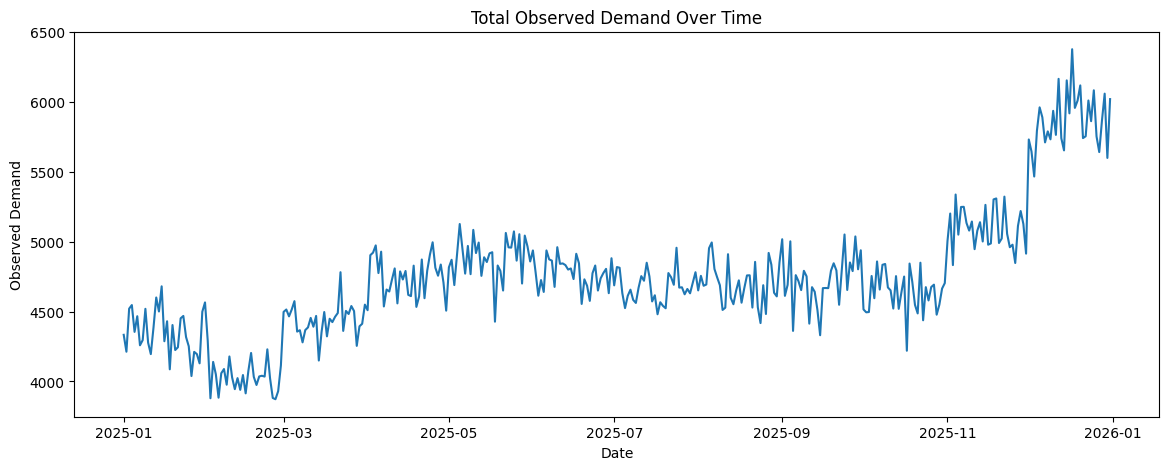

In [ ]:
daily_demand = (
    df.groupby("Date")["ObservedDemand"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(daily_demand["Date"], daily_demand["ObservedDemand"])
plt.xlabel("Date")
plt.ylabel("Observed Demand")
plt.title("Total Observed Demand Over Time")
plt.show()

In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

In [ ]:
group_cols = ["ProductID", "WarehouseID"]

df["Demand_Lag_1"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .shift(1)
)

df["Demand_Lag_7"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .shift(7)
)

df["Demand_Lag_14"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .shift(14)
)

In [ ]:
df["RollingMean_7"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .transform(
          lambda x: x.shift(1).rolling(7).mean()
      )
)

df["RollingMean_14"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .transform(
          lambda x: x.shift(1).rolling(14).mean()
      )
)

df["RollingStd_7"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .transform(
          lambda x: x.shift(1).rolling(7).std()
      )
)

In [ ]:
feature_columns = [
    "OpeningStock",
    "UnitsReceived",
    "ClosingStock",
    "Promotion",
    "UnitCost",
    "UnitPrice",

    "Month",
    "DayOfWeek",
    "WeekOfYear",
    "IsWeekend",

    "Demand_Lag_1",
    "Demand_Lag_7",
    "Demand_Lag_14",

    "RollingMean_7",
    "RollingMean_14",
    "RollingStd_7"
]

target = "ObservedDemand"

ml_df = df.dropna(
    subset=feature_columns + [target]
).copy()

print("ML dataset shape:", ml_df.shape)

ML dataset shape: (92664, 29)


In [ ]:
ml_df = ml_df.sort_values("Date")

unique_dates = np.sort(ml_df["Date"].unique())

split_index = int(len(unique_dates) * 0.80)
split_date = unique_dates[split_index]

train = ml_df[ml_df["Date"] < split_date]
test = ml_df[ml_df["Date"] >= split_date]

print("Split date:", split_date)

print(
    "Training:",
    train["Date"].min(),
    "to",
    train["Date"].max()
)

print(
    "Testing:",
    test["Date"].min(),
    "to",
    test["Date"].max()
)

Split date: 2025-10-22T00:00:00.000000000
Training: 2025-01-15 00:00:00 to 2025-10-21 00:00:00
Testing: 2025-10-22 00:00:00 to 2025-12-31 00:00:00


In [ ]:
X_train = train[feature_columns]
y_train = train[target]

X_test = test[feature_columns]
y_test = test[target]

print(X_train.shape)
print(X_test.shape)

(73920, 16)
(18744, 16)


In [ ]:
baseline_pred = test["Demand_Lag_1"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE : 8.571062740076824
Baseline RMSE: 14.754966177141998


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("----------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score  :", rf_r2)

Random Forest
----------------
MAE : 6.202204163642219
RMSE: 10.62511220742804
R2 Score  : 0.712949064403471


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("----------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost
----------------
MAE : 5.558555603027344
RMSE: 9.510245169478742
R²  : 0.7700278162956238


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Lag-1 Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        np.nan,
        rf_r2,
        xgb_r2
    ]
})

comparison = comparison.sort_values(
    "MAE"
).reset_index(drop=True)

display(comparison)

,Model,MAE,RMSE,R2
0,XGBoost,5.558556,9.510245,0.770028
1,Random Forest,6.202204,10.625112,0.712949
2,Lag-1 Baseline,8.571063,14.754966,NaN


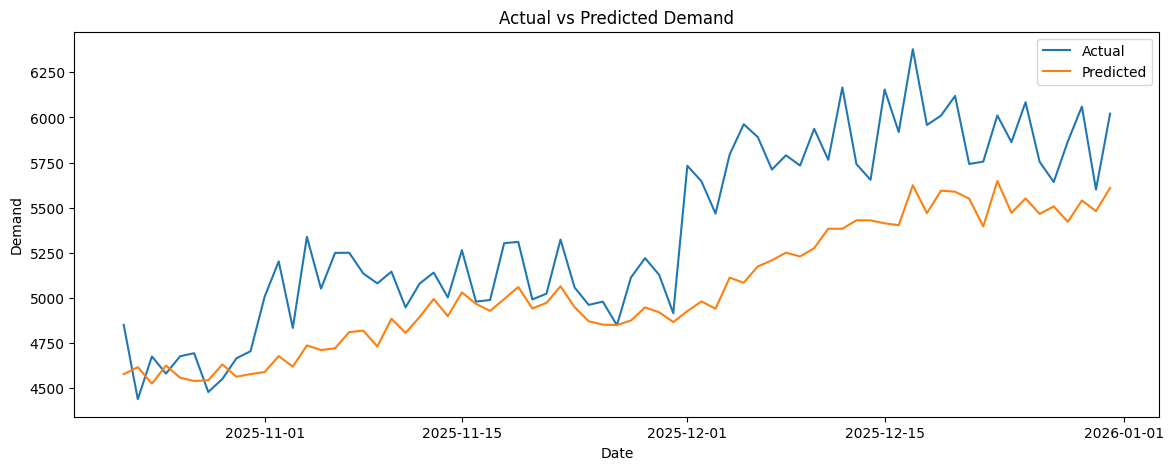

In [ ]:
results = test[
    ["Date", "ProductID", "WarehouseID", "ObservedDemand"]
].copy()

results["PredictedDemand"] = np.maximum(
    xgb_pred,
    0
)

daily_results = (
    results.groupby("Date")[
        ["ObservedDemand", "PredictedDemand"]
    ]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_results["Date"],
    daily_results["ObservedDemand"],
    label="Actual"
)

plt.plot(
    daily_results["Date"],
    daily_results["PredictedDemand"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Demand")
plt.legend()
plt.show()

In [ ]:
group_cols = ["ProductID", "WarehouseID"]

df = df.sort_values(
    ["ProductID", "WarehouseID", "Date"]
).copy()

df["DemandNext7Days"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .transform(
          lambda x: x.shift(-1)
                     .rolling(7)
                     .sum()
                     .shift(-6)
      )
)

df["DemandNext14Days"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .transform(
          lambda x: x.shift(-1)
                     .rolling(14)
                     .sum()
                     .shift(-13)
      )
)

df["DemandNext30Days"] = (
    df.groupby(group_cols)["ObservedDemand"]
      .transform(
          lambda x: x.shift(-1)
                     .rolling(30)
                     .sum()
                     .shift(-29)
      )
)

In [ ]:
display(
    df[
        [
            "Date",
            "ProductID",
            "WarehouseID",
            "ObservedDemand",
            "DemandNext7Days",
            "DemandNext14Days",
            "DemandNext30Days"
        ]
    ].head(40)
)

,Date,ProductID,WarehouseID,ObservedDemand,DemandNext7Days,DemandNext14Days,DemandNext30Days
0,2025-01-01,PROD0001,WH01,33,350.0,630.0,1388.0
264,2025-01-02,PROD0001,WH01,50,344.0,636.0,1411.0
528,2025-01-03,PROD0001,WH01,53,310.0,597.0,1403.0
792,2025-01-04,PROD0001,WH01,73,285.0,551.0,1359.0
1056,2025-01-05,PROD0001,WH01,41,303.0,568.0,1371.0
1320,2025-01-06,PROD0001,WH01,50,302.0,566.0,1359.0
1584,2025-01-07,PROD0001,WH01,20,301.0,597.0,1375.0
1848,2025-01-08,PROD0001,WH01,63,280.0,608.0,1360.0
2112,2025-01-09,PROD0001,WH01,44,292.0,615.0,1337.0
2376,2025-01-10,PROD0001,WH01,19,287.0,650.0,1363.0


In [ ]:
forecast_features = [
    "Promotion",
    "UnitCost",
    "UnitPrice",
    "Month",
    "DayOfWeek",
    "WeekOfYear",
    "IsWeekend",
    "Demand_Lag_1",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "RollingMean_7",
    "RollingMean_14",
    "RollingStd_7"
]

In [ ]:
forecast_df = df.dropna(
    subset=forecast_features + [
        "DemandNext7Days",
        "DemandNext14Days",
        "DemandNext30Days"
    ]
).copy()

forecast_df = forecast_df.sort_values("Date")

print("Forecast dataset:", forecast_df.shape)
print(
    forecast_df["Date"].min(),
    "to",
    forecast_df["Date"].max()
)

Forecast dataset: (84744, 32)
2025-01-15 00:00:00 to 2025-12-01 00:00:00


In [ ]:
unique_dates = np.sort(
    forecast_df["Date"].unique()
)

split_index = int(
    len(unique_dates) * 0.80
)

forecast_split_date = unique_dates[split_index]

train_forecast = forecast_df[
    forecast_df["Date"] < forecast_split_date
]

test_forecast = forecast_df[
    forecast_df["Date"] >= forecast_split_date
]

X_train_forecast = train_forecast[forecast_features]
X_test_forecast = test_forecast[forecast_features]

print("Split date:", forecast_split_date)
print("Training rows:", len(train_forecast))
print("Testing rows:", len(test_forecast))

Split date: 2025-09-28T00:00:00.000000000
Training rows: 67584
Testing rows: 17160


In [ ]:
from xgboost import XGBRegressor

def create_xgb_model():
    return XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

In [ ]:
model_7d = create_xgb_model()

model_7d.fit(
    X_train_forecast,
    train_forecast["DemandNext7Days"]
)

pred_7d = model_7d.predict(
    X_test_forecast
)

pred_7d = np.maximum(pred_7d, 0)

In [ ]:
model_14d = create_xgb_model()

model_14d.fit(
    X_train_forecast,
    train_forecast["DemandNext14Days"]
)

pred_14d = model_14d.predict(
    X_test_forecast
)

pred_14d = np.maximum(pred_14d, 0)

In [ ]:
model_30d = create_xgb_model()

model_30d.fit(
    X_train_forecast,
    train_forecast["DemandNext30Days"]
)

pred_30d = model_30d.predict(
    X_test_forecast
)

pred_30d = np.maximum(pred_30d, 0)

In [ ]:
def evaluate_forecast(actual, predicted, name):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Forecast": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [ ]:
forecast_evaluation = pd.DataFrame([

    evaluate_forecast(
        test_forecast["DemandNext7Days"],
        pred_7d,
        "7-Day"
    ),

    evaluate_forecast(
        test_forecast["DemandNext14Days"],
        pred_14d,
        "14-Day"
    ),

    evaluate_forecast(
        test_forecast["DemandNext30Days"],
        pred_30d,
        "30-Day"
    )

])

display(forecast_evaluation)

,Forecast,MAE,RMSE,R2
0,7-Day,19.682190,32.182360,0.913128
1,14-Day,34.329013,56.227473,0.933984
2,30-Day,74.083046,120.871460,0.937479


In [ ]:
def wape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    denominator = np.sum(np.abs(actual))

    if denominator == 0:
        return np.nan

    return (
        np.sum(np.abs(actual - predicted))
        / denominator
    ) * 100

print(
    "7-Day WAPE:",
    wape(
        test_forecast["DemandNext7Days"],
        pred_7d
    )
)

print(
    "14-Day WAPE:",
    wape(
        test_forecast["DemandNext14Days"],
        pred_14d
    )
)

print(
    "30-Day WAPE:",
    wape(
        test_forecast["DemandNext30Days"],
        pred_30d
    )
)

7-Day WAPE: 15.042184302157738
14-Day WAPE: 12.956387526751728
30-Day WAPE: 12.652204729493347


In [ ]:
forecast_results = test_forecast[
    [
        "Date",
        "ProductID",
        "ProductName",
        "Category",
        "WarehouseID",
        "WarehouseName"
    ]
].copy()

forecast_results["ActualDemand_7D"] = (
    test_forecast["DemandNext7Days"].values
)

forecast_results["ForecastDemand_7D"] = pred_7d

forecast_results["ActualDemand_14D"] = (
    test_forecast["DemandNext14Days"].values
)

forecast_results["ForecastDemand_14D"] = pred_14d

forecast_results["ActualDemand_30D"] = (
    test_forecast["DemandNext30Days"].values
)

forecast_results["ForecastDemand_30D"] = pred_30d

display(forecast_results.head())

,Date,ProductID,ProductName,Category,WarehouseID,WarehouseName,ActualDemand_7D,ForecastDemand_7D,ActualDemand_14D,ForecastDemand_14D,ActualDemand_30D,ForecastDemand_30D
71428,2025-09-28,PROD0052,Snacks Item 52,Grocery,WH04,Southeast DC,407.0,433.702637,802.0,849.682007,1646.0,1773.432495
71403,2025-09-28,PROD0045,Garden Tools Item 45,Home & Garden,WH02,Central DC,25.0,27.620935,50.0,54.229763,105.0,118.320816
71481,2025-09-28,PROD0070,Team Sports Item 70,Sports & Outdoors,WH02,Central DC,20.0,26.796244,46.0,53.683891,101.0,113.142265
71494,2025-09-28,PROD0074,Headphones Item 74,Electronics,WH01,Northeast DC,59.0,76.702118,141.0,155.203308,308.0,345.283356
71301,2025-09-28,PROD0007,Canned Goods Item 7,Grocery,WH03,West Coast DC,358.0,383.868439,717.0,714.190430,1594.0,1514.987793


In [ ]:
print(df.columns.tolist())

print("\nStockoutFlag values:")
print(df["StockoutFlag"].value_counts(dropna=False))

df = df.sort_values(
    ["ProductID", "WarehouseID", "Date"]
).reset_index(drop=True)

group_cols = [
    "ProductID",
    "WarehouseID"
]

print("Data sorted successfully.")

future_flags = []

for i in range(1, 8):

    future_flag = (
        df.groupby(group_cols)["StockoutFlag"]
          .shift(-i)
    )

    future_flags.append(future_flag)

future_stockouts = pd.concat(
    future_flags,
    axis=1
)

future_stockouts.columns = [
    "Day_1",
    "Day_2",
    "Day_3",
    "Day_4",
    "Day_5",
    "Day_6",
    "Day_7"
]

display(future_stockouts.head(20))

['Date', 'ProductID', 'ProductName', 'Category', 'SupplierID', 'WarehouseID', 'WarehouseName', 'OpeningStock', 'UnitsReceived', 'UnitsSold', 'LostSales', 'ClosingStock', 'ObservedDemand', 'StockoutFlag', 'Promotion', 'UnitCost', 'UnitPrice', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'IsWeekend', 'Demand_Lag_1', 'Demand_Lag_7', 'Demand_Lag_14', 'RollingMean_7', 'RollingMean_14', 'RollingStd_7', 'DemandNext7Days', 'DemandNext14Days', 'DemandNext30Days', 'StockoutNext7Days']

StockoutFlag values:
StockoutFlag
0    90824
1     5536
Name: count, dtype: int64
Data sorted successfully.


,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df["StockoutNext7Days"] = (
    future_stockouts.max(axis=1)
)

df["CompleteFuture7D"] = (
    future_stockouts.notna().all(axis=1)
)

df.loc[
    ~df["CompleteFuture7D"],
    "StockoutNext7Days"
] = np.nan

print(
    df["CompleteFuture7D"]
    .value_counts()
)
print("Stockout target counts:")

print(
    df["StockoutNext7Days"]
    .value_counts(dropna=False)
)
print("\nStockout target percentages:")

print(
    df["StockoutNext7Days"]
    .value_counts(
        normalize=True,
        dropna=False
    ) * 100
)

CompleteFuture7D
True     94512
False     1848
Name: count, dtype: int64
Stockout target counts:
StockoutNext7Days
0.0    81434
1.0    13078
NaN     1848
Name: count, dtype: int64

Stockout target percentages:
StockoutNext7Days
0.0    84.510170
1.0    13.572022
NaN     1.917808
Name: proportion, dtype: float64


In [ ]:
display(
    df[
        [
            "Date",
            "ProductID",
            "ProductName",
            "WarehouseID",
            "WarehouseName",
            "ClosingStock",
            "ObservedDemand",
            "StockoutFlag",
            "StockoutNext7Days",
            "CompleteFuture7D"
        ]
    ].head(30)
)

,Date,ProductID,ProductName,WarehouseID,WarehouseName,ClosingStock,ObservedDemand,StockoutFlag,StockoutNext7Days,CompleteFuture7D
0,2025-01-01,PROD0001,Dairy Item 1,WH01,Northeast DC,1019,33,0,0.0,True
1,2025-01-02,PROD0001,Dairy Item 1,WH01,Northeast DC,969,50,0,0.0,True
2,2025-01-03,PROD0001,Dairy Item 1,WH01,Northeast DC,916,53,0,0.0,True
3,2025-01-04,PROD0001,Dairy Item 1,WH01,Northeast DC,843,73,0,0.0,True
4,2025-01-05,PROD0001,Dairy Item 1,WH01,Northeast DC,802,41,0,0.0,True
5,2025-01-06,PROD0001,Dairy Item 1,WH01,Northeast DC,752,50,0,0.0,True
6,2025-01-07,PROD0001,Dairy Item 1,WH01,Northeast DC,732,20,0,0.0,True
7,2025-01-08,PROD0001,Dairy Item 1,WH01,Northeast DC,669,63,0,0.0,True
8,2025-01-09,PROD0001,Dairy Item 1,WH01,Northeast DC,625,44,0,0.0,True
9,2025-01-10,PROD0001,Dairy Item 1,WH01,Northeast DC,606,19,0,0.0,True


In [ ]:
sample_product = df["ProductID"].iloc[0]
sample_warehouse = df["WarehouseID"].iloc[0]

sample = df[
    (df["ProductID"] == sample_product)
    &
    (df["WarehouseID"] == sample_warehouse)
][
    [
        "Date",
        "ProductID",
        "WarehouseID",
        "ClosingStock",
        "StockoutFlag",
        "StockoutNext7Days"
    ]
]

display(sample.head(30))

,Date,ProductID,WarehouseID,ClosingStock,StockoutFlag,StockoutNext7Days
0,2025-01-01,PROD0001,WH01,1019,0,0.0
1,2025-01-02,PROD0001,WH01,969,0,0.0
2,2025-01-03,PROD0001,WH01,916,0,0.0
3,2025-01-04,PROD0001,WH01,843,0,0.0
4,2025-01-05,PROD0001,WH01,802,0,0.0
5,2025-01-06,PROD0001,WH01,752,0,0.0
6,2025-01-07,PROD0001,WH01,732,0,0.0
7,2025-01-08,PROD0001,WH01,669,0,0.0
8,2025-01-09,PROD0001,WH01,625,0,0.0
9,2025-01-10,PROD0001,WH01,606,0,0.0


In [ ]:
print(
    df[
        [
            "StockoutNext7Days",
            "CompleteFuture7D"
        ]
    ].head()
)

   StockoutNext7Days  CompleteFuture7D
0                0.0              True
1                0.0              True
2                0.0              True
3                0.0              True
4                0.0              True


In [ ]:
df["StockoutNext7Days"].value_counts(
    normalize=True,
    dropna=False
) * 100

,proportion
StockoutNext7Days,
0.0,84.510170
1.0,13.572022
NaN,1.917808


In [ ]:
stockout_features = [
    "OpeningStock",
    "ClosingStock",
    "UnitsReceived",
    "ObservedDemand",
    "Promotion",
    "UnitCost",
    "UnitPrice",

    "Month",
    "DayOfWeek",
    "WeekOfYear",
    "IsWeekend",

    "Demand_Lag_1",
    "Demand_Lag_7",
    "Demand_Lag_14",

    "RollingMean_7",
    "RollingMean_14",
    "RollingStd_7"
]

print("Number of features:", len(stockout_features))

print("\nFeatures:")
for feature in stockout_features:
    print("-", feature)

Number of features: 17

Features:
- OpeningStock
- ClosingStock
- UnitsReceived
- ObservedDemand
- Promotion
- UnitCost
- UnitPrice
- Month
- DayOfWeek
- WeekOfYear
- IsWeekend
- Demand_Lag_1
- Demand_Lag_7
- Demand_Lag_14
- RollingMean_7
- RollingMean_14
- RollingStd_7


In [ ]:
print(
    df[stockout_features]
    .isnull()
    .sum()
)

OpeningStock         0
ClosingStock         0
UnitsReceived        0
ObservedDemand       0
Promotion            0
UnitCost             0
UnitPrice            0
Month                0
DayOfWeek            0
WeekOfYear           0
IsWeekend            0
Demand_Lag_1       264
Demand_Lag_7      1848
Demand_Lag_14     3696
RollingMean_7     1848
RollingMean_14    3696
RollingStd_7      1848
dtype: int64


In [ ]:
stock_df = df.dropna(
    subset=stockout_features + [
        "StockoutNext7Days"
    ]
).copy()

stock_df["StockoutNext7Days"] = (
    stock_df["StockoutNext7Days"]
    .astype(int)
)

stock_df = stock_df.sort_values(
    "Date"
).reset_index(drop=True)

print("Original rows:", len(df))
print("ML rows:", len(stock_df))

Original rows: 96360
ML rows: 90816


In [ ]:
class_counts = (
    stock_df["StockoutNext7Days"]
    .value_counts()
    .sort_index()
)

class_percent = (
    stock_df["StockoutNext7Days"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent)

Class counts:
StockoutNext7Days
0    77901
1    12915
Name: count, dtype: int64

Class percentages:
StockoutNext7Days
0    85.778938
1    14.221062
Name: proportion, dtype: float64


In [ ]:
unique_dates = np.sort(
    stock_df["Date"].unique()
)

split_index = int(
    len(unique_dates) * 0.80
)

stock_split_date = unique_dates[split_index]

stock_train = stock_df[
    stock_df["Date"] < stock_split_date
].copy()

stock_test = stock_df[
    stock_df["Date"] >= stock_split_date
].copy()

print("Split Date:", stock_split_date)

print("\nTraining period:")
print(
    stock_train["Date"].min(),
    "to",
    stock_train["Date"].max()
)

print("\nTesting period:")
print(
    stock_test["Date"].min(),
    "to",
    stock_test["Date"].max()
)

print("\nTraining rows:", len(stock_train))
print("Testing rows :", len(stock_test))

Split Date: 2025-10-17T00:00:00.000000000

Training period:
2025-01-15 00:00:00 to 2025-10-16 00:00:00

Testing period:
2025-10-17 00:00:00 to 2025-12-24 00:00:00

Training rows: 72600
Testing rows : 18216


In [ ]:
X_train_stock = stock_train[
    stockout_features
]

y_train_stock = stock_train[
    "StockoutNext7Days"
]

X_test_stock = stock_test[
    stockout_features
]

y_test_stock = stock_test[
    "StockoutNext7Days"
]

print("X Train:", X_train_stock.shape)
print("X Test :", X_test_stock.shape)

print("y Train:", y_train_stock.shape)
print("y Test :", y_test_stock.shape)

X Train: (72600, 17)
X Test : (18216, 17)
y Train: (72600,)
y Test : (18216,)


In [ ]:
print("TRAIN DISTRIBUTION")

print(
    y_train_stock
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nTEST DISTRIBUTION")

print(
    y_test_stock
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

TRAIN DISTRIBUTION
StockoutNext7Days
0    87.139118
1    12.860882
Name: proportion, dtype: float64

TEST DISTRIBUTION
StockoutNext7Days
0    80.357927
1    19.642073
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

stockout_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

stockout_rf.fit(
    X_train_stock,
    y_train_stock
)

print("✓ Stockout Random Forest trained successfully.")

✓ Stockout Random Forest trained successfully.


In [ ]:
stockout_probability = (
    stockout_rf.predict_proba(
        X_test_stock
    )[:, 1]
)

stockout_prediction = (
    stockout_probability >= 0.50
).astype(int)

print(
    "Predicted stockouts:",
    stockout_prediction.sum()
)

print(
    "Average predicted probability:",
    stockout_probability.mean()
)

Predicted stockouts: 3908
Average predicted probability: 0.20222325506205144


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("CLASSIFICATION REPORT")
print("---------------------")

print(
    classification_report(
        y_test_stock,
        stockout_prediction,
        digits=4
    )
)

cm = confusion_matrix(
    y_test_stock,
    stockout_prediction
)

print("\nCONFUSION MATRIX")
print("----------------")

print(cm)

roc_auc = roc_auc_score(
    y_test_stock,
    stockout_probability
)

pr_auc = average_precision_score(
    y_test_stock,
    stockout_probability
)

print("\nROC-AUC:", roc_auc)
print("PR-AUC :", pr_auc)

CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

           0     0.9501    0.9287    0.9393     14638
           1     0.7329    0.8004    0.7652      3578

    accuracy                         0.9035     18216
   macro avg     0.8415    0.8646    0.8522     18216
weighted avg     0.9074    0.9035    0.9051     18216


CONFUSION MATRIX
----------------
[[13594  1044]
 [  714  2864]]

ROC-AUC: 0.9548477679059327
PR-AUC : 0.7657194576379971


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        stockout_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_stock,
        predictions
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,

         "Accuracy": accuracy_score(
            y_test_stock,
            predictions
        ),

        "Precision": precision_score(
            y_test_stock,
            predictions
        ),
        "Recall": recall_score(
            y_test_stock,
            predictions
        ),
        "F1": f1_score(
            y_test_stock,
            predictions
        ),
        "FalsePositives": fp,
        "FalseNegatives": fn,
        "TruePositives": tp,
        "TrueNegatives": tn
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Threshold,Accuracy,Precision,Recall,F1,FalsePositives,FalseNegatives,TruePositives,TrueNegatives
0,0.30,0.893061,0.667903,0.906093,0.768975,1612,336,3242,13026
1,0.35,0.897453,0.684585,0.886249,0.772473,1461,407,3171,13177
2,0.40,0.900143,0.700662,0.858301,0.771511,1312,507,3071,13326
3,0.45,0.901790,0.716011,0.828675,0.768234,1176,613,2965,13462
4,0.50,0.903491,0.732856,0.800447,0.765162,1044,714,2864,13594
5,0.55,0.902229,0.746637,0.760201,0.753358,923,858,2720,13715
6,0.60,0.900637,0.760613,0.721073,0.740316,812,998,2580,13826
7,0.65,0.896410,0.771254,0.671884,0.718148,713,1174,2404,13925
8,0.70,0.889548,0.781655,0.607323,0.683548,607,1405,2173,14031


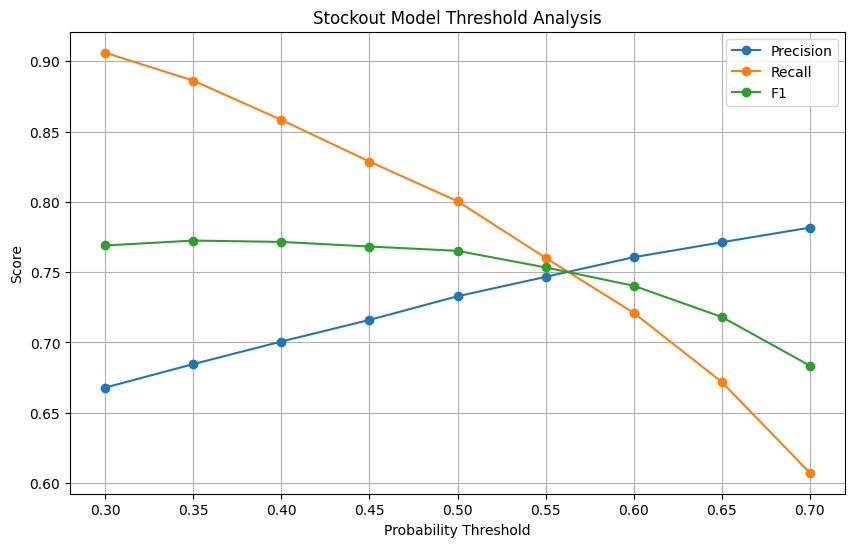

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Stockout Model Threshold Analysis")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
eligible = threshold_df[
    threshold_df["Recall"] >= 0.85
]

display(eligible)

,Threshold,Precision,Recall,F1,FalsePositives,FalseNegatives,TruePositives,TrueNegatives
0,0.30,0.667903,0.906093,0.768975,1612,336,3242,13026
1,0.35,0.684585,0.886249,0.772473,1461,407,3171,13177
2,0.40,0.700662,0.858301,0.771511,1312,507,3071,13326


In [ ]:
if len(eligible) > 0:

    best_row = eligible.sort_values(
        "Precision",
        ascending=False
    ).iloc[0]

    selected_threshold = (
        best_row["Threshold"]
    )

else:

    selected_threshold = 0.50

print(
    "Selected threshold:",
    selected_threshold
)

Selected threshold: 0.4


In [ ]:
selected_threshold = 0.40

stockout_prediction_final = (
    stockout_probability >= selected_threshold
).astype(int)

print("Selected Threshold:", selected_threshold)

Selected Threshold: 0.4


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

final_accuracy = accuracy_score(
    y_test_stock,
    stockout_prediction_final
)

final_precision = precision_score(
    y_test_stock,
    stockout_prediction_final
)

final_recall = recall_score(
    y_test_stock,
    stockout_prediction_final
)

final_f1 = f1_score(
    y_test_stock,
    stockout_prediction_final
)

final_roc_auc = roc_auc_score(
    y_test_stock,
    stockout_probability
)

final_pr_auc = average_precision_score(
    y_test_stock,
    stockout_probability
)

print("FINAL STOCKOUT MODEL PERFORMANCE")
print("--------------------------------")

print(f"Threshold : {selected_threshold:.2f}")
print(f"Accuracy  : ({final_accuracy*100:.2f}%)")
print(f"Precision : ({final_precision*100:.2f}%)")
print(f"Recall    : ({final_recall*100:.2f}%)")
print(f"F1 Score  : ({final_f1*100:.2f}%)")
print(f"ROC-AUC   : {final_roc_auc:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")

FINAL STOCKOUT MODEL PERFORMANCE
--------------------------------
Threshold : 0.40
Accuracy  : (90.01%)
Precision : (70.07%)
Recall    : (85.83%)
F1 Score  : (77.15%)
ROC-AUC   : 0.9548
PR-AUC    : 0.7657


In [ ]:
print(
    classification_report(
        y_test_stock,
        stockout_prediction_final,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9633    0.9104    0.9361     14638
           1     0.7007    0.8583    0.7715      3578

    accuracy                         0.9001     18216
   macro avg     0.8320    0.8843    0.8538     18216
weighted avg     0.9118    0.9001    0.9038     18216



In [ ]:
print(
    classification_report(
        y_test_stock,
        stockout_prediction_final,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9633    0.9104    0.9361     14638
           1     0.7007    0.8583    0.7715      3578

    accuracy                         0.9001     18216
   macro avg     0.8320    0.8843    0.8538     18216
weighted avg     0.9118    0.9001    0.9038     18216



In [ ]:
final_cm = confusion_matrix(
    y_test_stock,
    stockout_prediction_final
)

print("Confusion Matrix:")
print(final_cm)

tn, fp, fn, tp = final_cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix:
[[13326  1312]
 [  507  3071]]

True Negatives : 13326
False Positives: 1312
False Negatives: 507
True Positives : 3071


In [ ]:
stockout_model_metrics = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],

    "Value": [
        selected_threshold,
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
        final_pr_auc,
        tn,
        fp,
        fn,
        tp
    ]
})

display(stockout_model_metrics)

,Metric,Value
0,Threshold,0.400000
1,Accuracy,0.900143
2,Precision,0.700662
3,Recall,0.858301
4,F1 Score,0.771511
5,ROC-AUC,0.954848
6,PR-AUC,0.765719
7,True Negatives,13326.000000
8,False Positives,1312.000000
9,False Negatives,507.000000


In [ ]:
stock_results = stock_test[
    [
        "Date",
        "ProductID",
        "ProductName",
        "Category",
        "WarehouseID",
        "WarehouseName",
        "ClosingStock",
        "ObservedDemand",
        "StockoutNext7Days"
    ]
].copy()

stock_results["StockoutProbability"] = (
    stockout_probability
)

stock_results["PredictedStockout"] = (
    stockout_prediction_final
)
stock_results["ModelThreshold"] = (
    selected_threshold
)

In [ ]:
stock_results["StockoutRisk"] = pd.cut(
    stock_results["StockoutProbability"],
    bins=[
        -0.001,
        0.30,
        0.60,
        1.001
    ],
    labels=[
        "LOW",
        "MEDIUM",
        "HIGH"
    ]
)

In [ ]:
display(
    stock_results.sort_values(
        "StockoutProbability",
        ascending=False
    ).head(20)
)

,Date,ProductID,ProductName,Category,WarehouseID,WarehouseName,ClosingStock,ObservedDemand,StockoutNext7Days,StockoutProbability,PredictedStockout,ModelThreshold,StockoutRisk
88441,2025-12-16,PROD0005,Headphones Item 5,Electronics,WH02,Central DC,4,18,1,0.963057,1,0.4,HIGH
80340,2025-11-15,PROD0005,Headphones Item 5,Electronics,WH03,West Coast DC,0,17,0,0.961526,1,0.4,HIGH
88965,2025-12-17,PROD0005,Headphones Item 5,Electronics,WH02,Central DC,0,14,1,0.960141,1,0.4,HIGH
79826,2025-11-13,PROD0005,Headphones Item 5,Electronics,WH03,West Coast DC,0,26,1,0.959993,1,0.4,HIGH
84173,2025-11-29,PROD0053,Athletic Footwear Item 53,Sports & Outdoors,WH03,West Coast DC,0,13,1,0.959330,1,0.4,HIGH
82797,2025-11-24,PROD0068,Accessories Item 68,Apparel,WH03,West Coast DC,0,21,1,0.958019,1,0.4,HIGH
79016,2025-11-10,PROD0090,Men's Tops Item 90,Apparel,WH01,Northeast DC,0,13,1,0.957813,1,0.4,HIGH
84490,2025-12-01,PROD0027,Men's Tops Item 27,Apparel,WH04,Southeast DC,0,28,0,0.957650,1,0.4,HIGH
80153,2025-11-14,PROD0005,Headphones Item 5,Electronics,WH03,West Coast DC,0,18,1,0.957092,1,0.4,HIGH
83085,2025-11-25,PROD0068,Accessories Item 68,Apparel,WH03,West Coast DC,0,18,0,0.956051,1,0.4,HIGH


In [ ]:
risk_distribution = (
    stock_results["StockoutRisk"]
    .value_counts()
)

display(risk_distribution)

risk_percentage = (
    stock_results["StockoutRisk"]
    .value_counts(normalize=True)
    * 100
)

display(risk_percentage)

,count
StockoutRisk,
LOW,13362
HIGH,3392
MEDIUM,1462


,proportion
StockoutRisk,
LOW,73.353096
HIGH,18.620993
MEDIUM,8.025911


In [ ]:
stock_importance = pd.DataFrame({
    "Feature": stockout_features,
    "Importance":
        stockout_rf.feature_importances_
})

stock_importance = (
    stock_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(stock_importance)

,Feature,Importance
0,ClosingStock,0.398673
1,OpeningStock,0.271143
2,RollingMean_14,0.069079
3,RollingMean_7,0.052942
4,ObservedDemand,0.028203
5,WeekOfYear,0.025143
6,Demand_Lag_1,0.023470
7,RollingStd_7,0.020266
8,UnitPrice,0.020034
9,UnitCost,0.019577


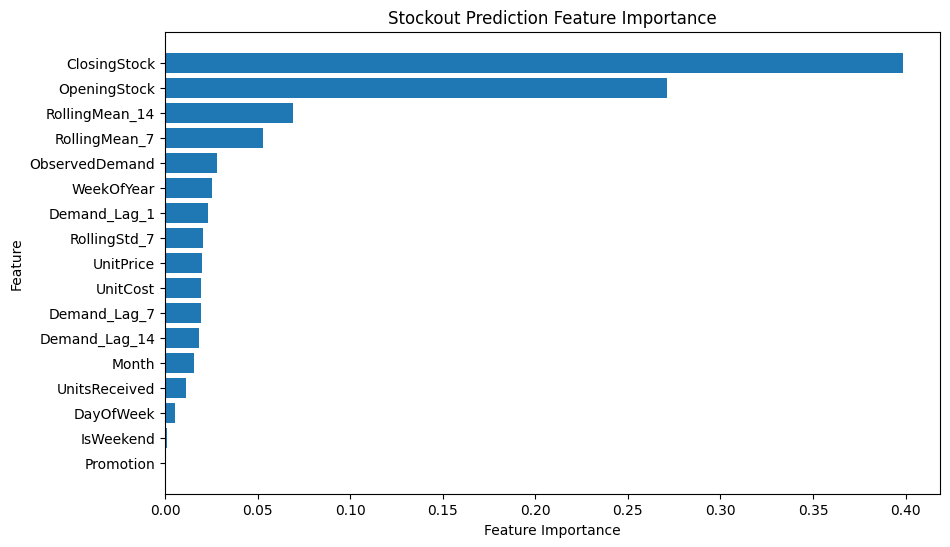

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    stock_importance["Feature"],
    stock_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Stockout Prediction Feature Importance"
)

plt.show()

In [ ]:
stock_results.to_csv(
    "Stockout_Risk_Results.csv",
    index=False
)

In [ ]:
threshold_df.to_csv(
    "Stockout_Threshold_Analysis.csv",
    index=False
)

In [ ]:
stock_importance.to_csv(
    "Stockout_Feature_Importance.csv",
    index=False
)

In [ ]:
stockout_model_metrics.to_csv(
    "Stockout_Model_Metrics.csv",
    index=False
)

In [ ]:
print("Files created successfully:")

print("1. Stockout_Risk_Results.csv")
print("2. Stockout_Threshold_Analysis.csv")
print("3. Stockout_Feature_Importance.csv")
print("4. Stockout_Model_Metrics.csv")

Files created successfully:
1. Stockout_Risk_Results.csv
2. Stockout_Threshold_Analysis.csv
3. Stockout_Feature_Importance.csv
4. Stockout_Model_Metrics.csv


In [ ]:
print("forecast_results exists:", "forecast_results" in globals())

forecast_results exists: True


In [ ]:
forecast_results.to_csv(
    "Demand_Forecast_Results.csv",
    index=False
)

print("Demand_Forecast_Results.csv created successfully.")

Demand_Forecast_Results.csv created successfully.


In [ ]:
import os

print(os.path.exists("Demand_Forecast_Results.csv"))

True
